In [6]:
# import numpy as np
# import glob
# import lgdo.lh5 as lh5
# import os, json
# import copy
# from pathlib import Path
# import shutil
# import glob
import matplotlib.pyplot as plt
# from matplotlib.backends.backend_pdf import PdfPages
# from pygama.pargen.utils import load_data
from legendmeta import LegendMetadata
from dbetto import Props, TextDB, AttrsDict
# import pandas as pd
from tqdm.notebook import tqdm
import awkward as ak
# import polars as pl

from bosonic_dm.io import get_values_sorted
# from bosonic_dm.resolution import weighted_resolution_from_nested_dict as wres_full
# from bosonic_dm.resolution import weighted_resolution_per_detector as wres_det
# from bosonic_dm.resolution import weighted_value_per_det_type as wval_dtype
# from bosonic_dm.resolution import weighted_resolution_per_detector_type as wres_dtype
# from bosonic_dm.resolution import get_eres_per_detector
import bosonic_dm.plotting.resolution as rex

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
version = "v2.1.5"
base = f"/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/{version}/"
scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"
# metadata2_path = os.environ["METADATA"]
metadata2_path = "/global/homes/b/borrfran/workspace/l200/legend-metadata"
config = Props.read_from(base+"/config.json", subst_pathvar=True)['setups']['l200']['paths']


meta = LegendMetadata(config['metadata'])
meta2 = LegendMetadata(metadata2_path)

timestamp = meta.dataprod.runinfo.p03.r000.phy.start_key

chmap = meta.channelmap(timestamp)
chmap_ak = ak.Array(chmap.group("system").geds.values())

DET_TYPES = ("BEGe", "COAX", "ICPC", "PPC")
DET_TYPE_MAP = {"B": "BEGe", "C": "COAX", "V": "ICPC", "P": "PPC"}

simulated_energies = list(range(200, 1100, 100))

outdir_name = "./v1/parquet/"
dictionaries_dir = "./v1/dictionaries"

eres_dict = Props.read_from(f"{dictionaries_dir}/eres_dict.yaml")
rawid_by_det_type = Props.read_from(f'{dictionaries_dir}/rawid_by_det_type.yaml')

could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd85f568c20>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd85f568810>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd85f568b30>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd85f569350>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd85f58c180>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd85f58c1d0>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldat

FileNotFoundError: [Errno 2] No such file or directory: 'v1/dictionaries/eres_dict.yaml'

  0%|          | 0/9 [00:00<?, ?it/s]

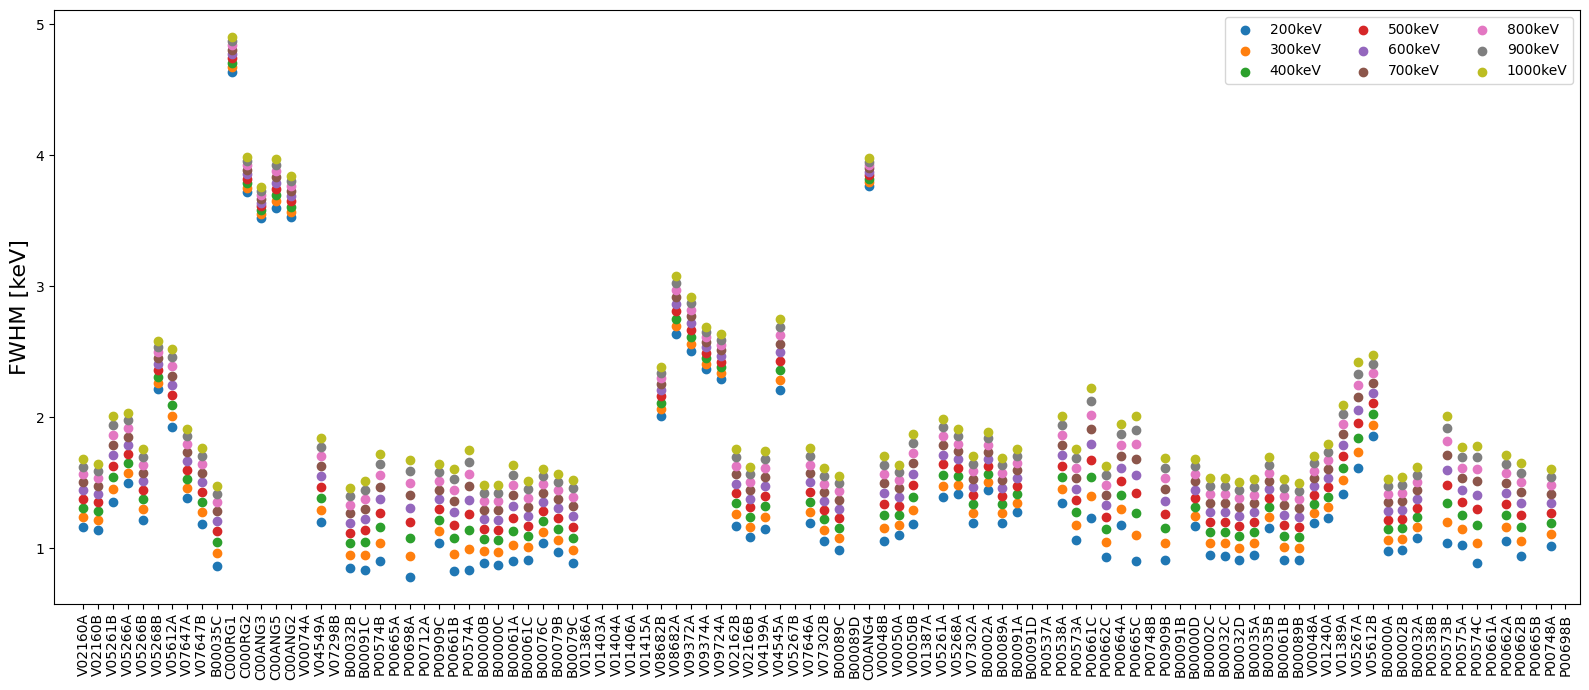

In [11]:
ges_sorted = chmap_ak.name

fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

for ene in tqdm(simulated_energies):
    
    keys, values = get_values_sorted(eres_dict[ene], ges_sorted, key='fwhm')
    tag = f'{ene}keV'
    ax.scatter(keys, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

ax.set_ylabel(r"FWHM [keV]", fontsize = 16)
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
plt.legend(ncol = 3)
# Padding sotto per non tagliare le etichette
plt.tight_layout()
# plt.savefig(f"./plots/{interaction}/FC-efficiency_{interaction}.png", dpi=500)
plt.show()


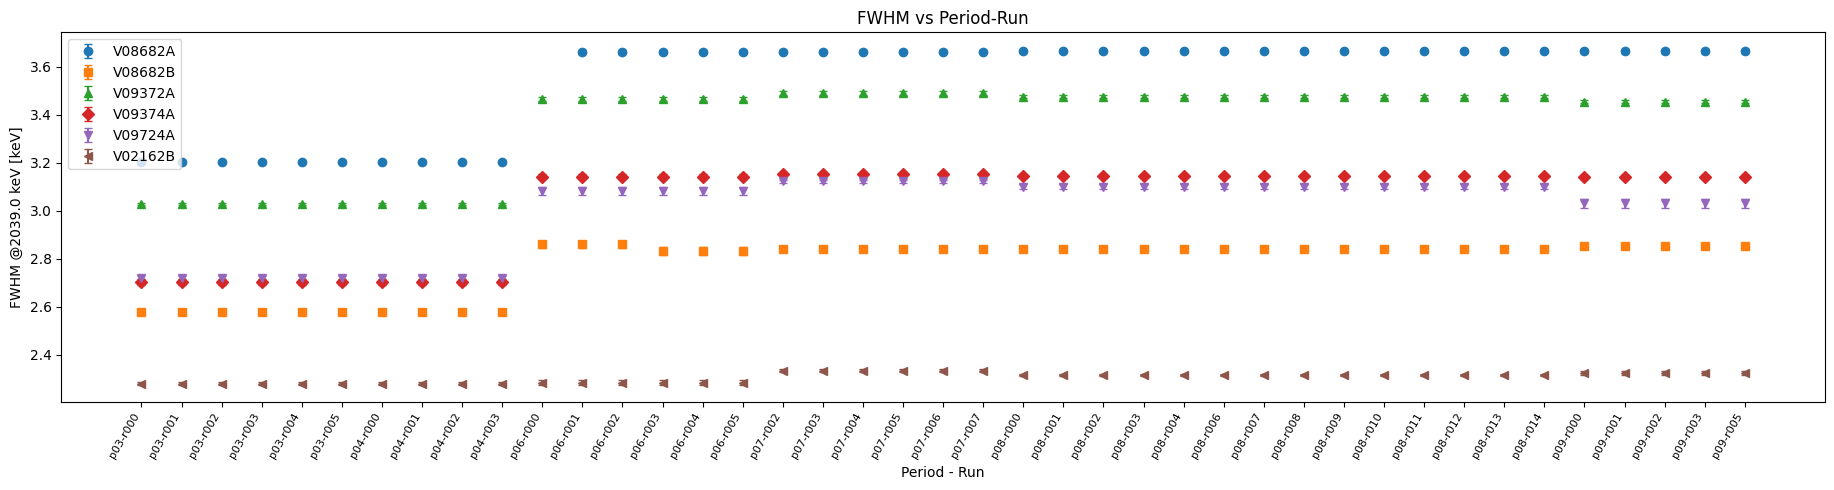

In [22]:
rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=["V08682A", "V08682B", "V09372A", "V09374A", "V09724A", "V02162B"],
    energy=2039.0,
    fig_path="plots/BEGe.png",
)


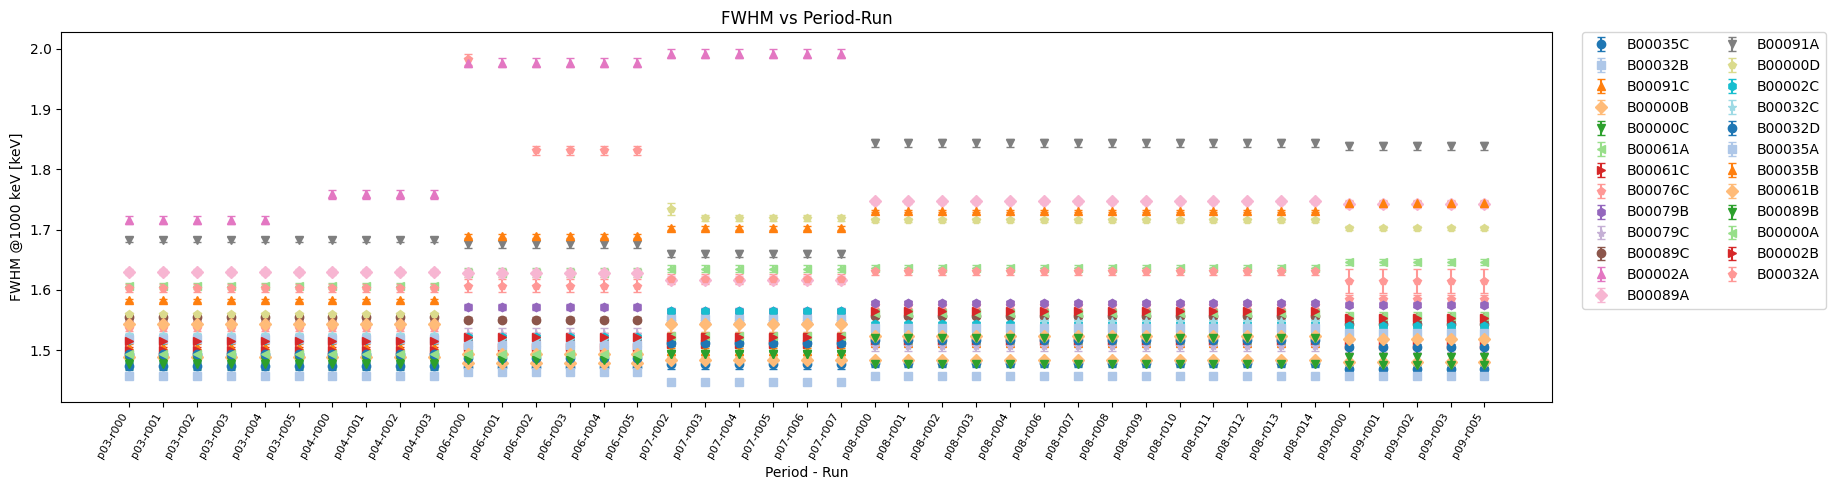

In [3]:
BEGe = [name for name in chmap.group('type')['bege'].map('name')]

rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=BEGe,
    energy=1000,
    fig_path="plots/grouping/BEGe.png",
)


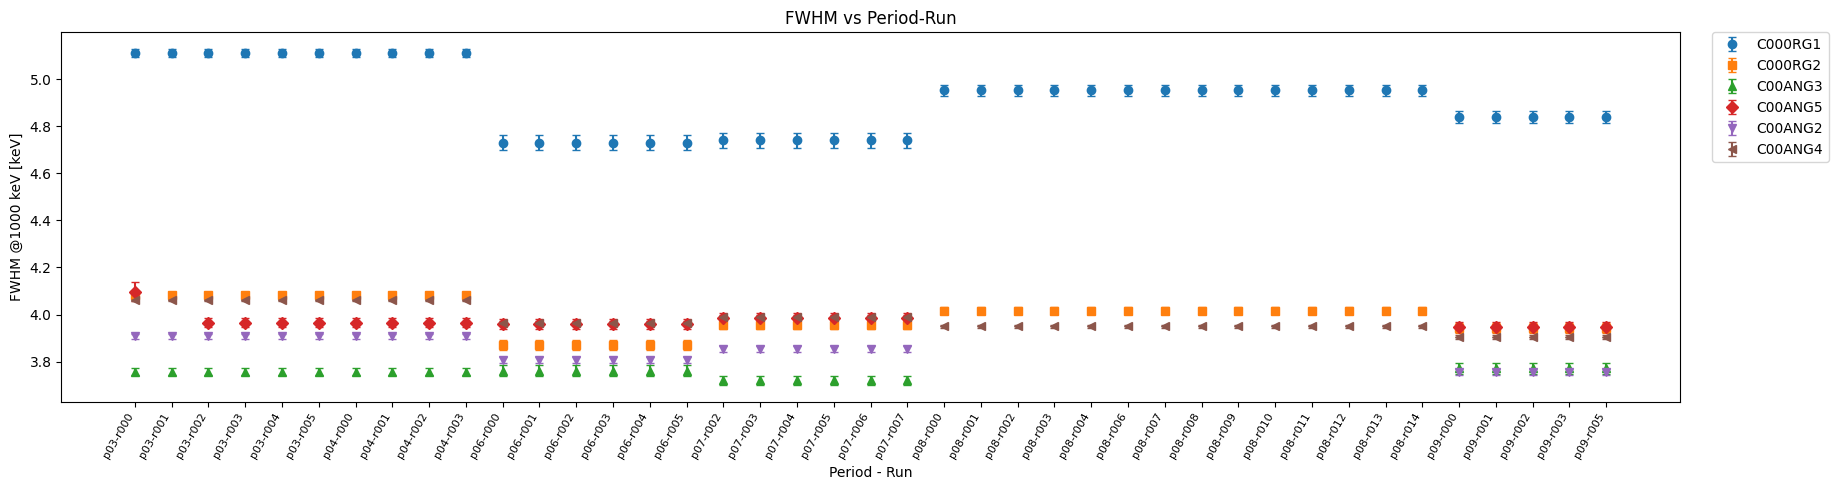

In [4]:
COAX = [name for name in chmap.group('type')['coax'].map('name')]

rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=COAX,
    energy=1000,
    fig_path="plots/grouping/COAX.png",
)



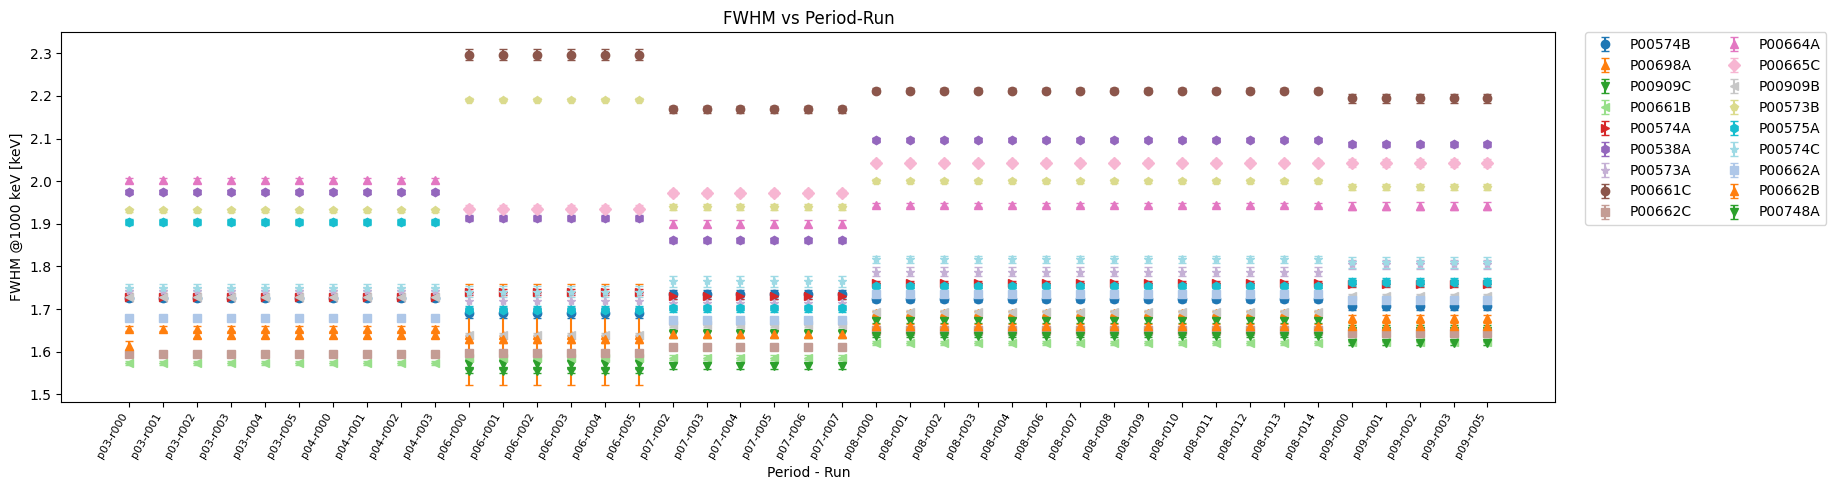

In [5]:
PPC = [name for name in chmap.group('type')['ppc'].map('name')]

rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=PPC,
    energy=1000,
    fig_path="plots/grouping/PPC.png",
)



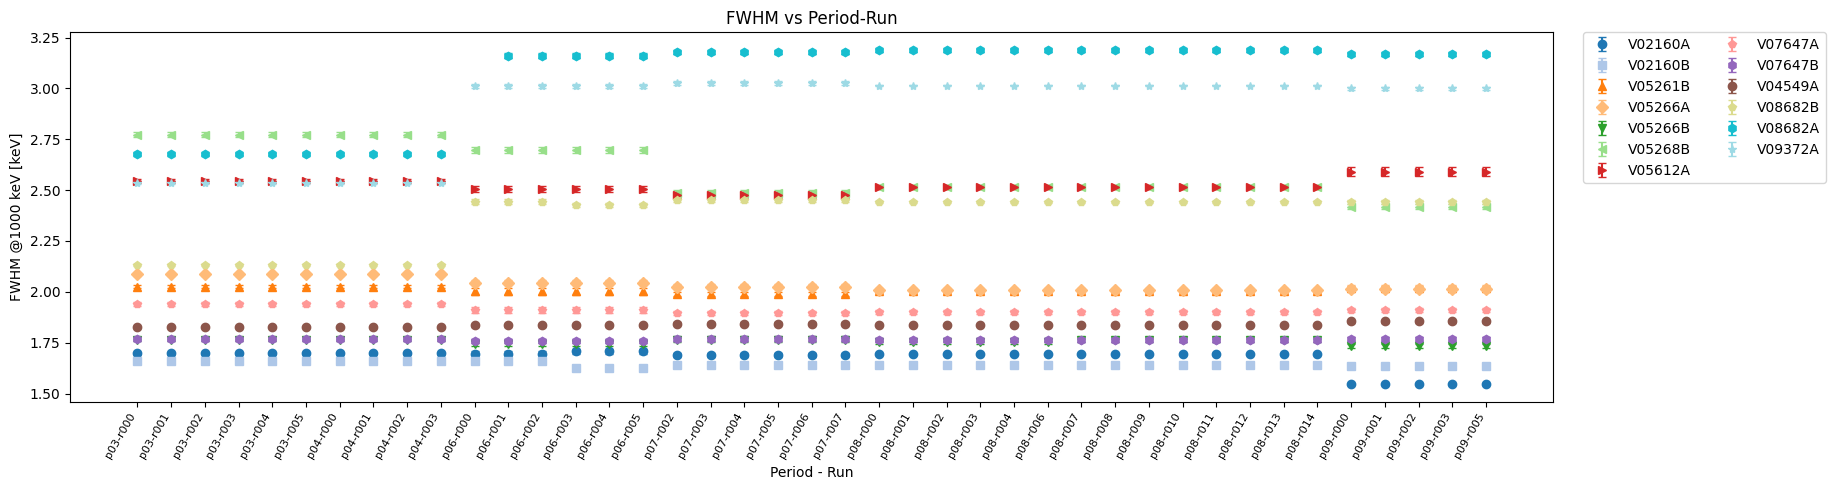

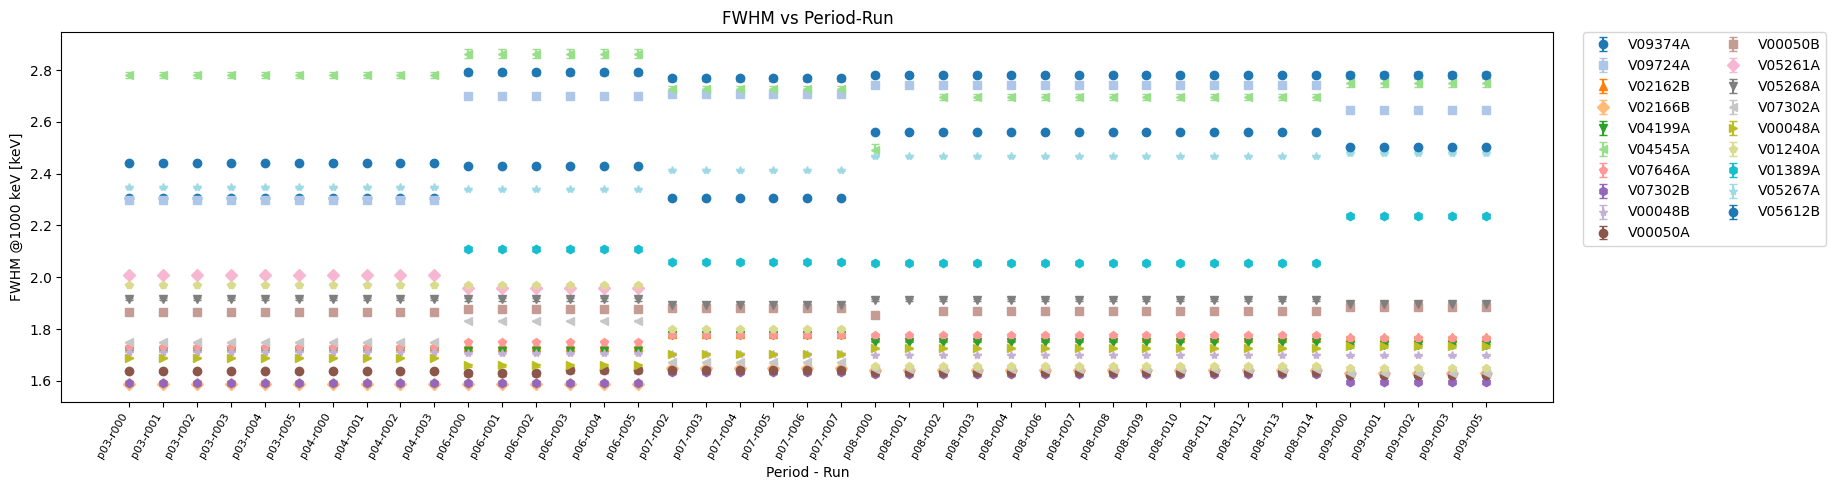

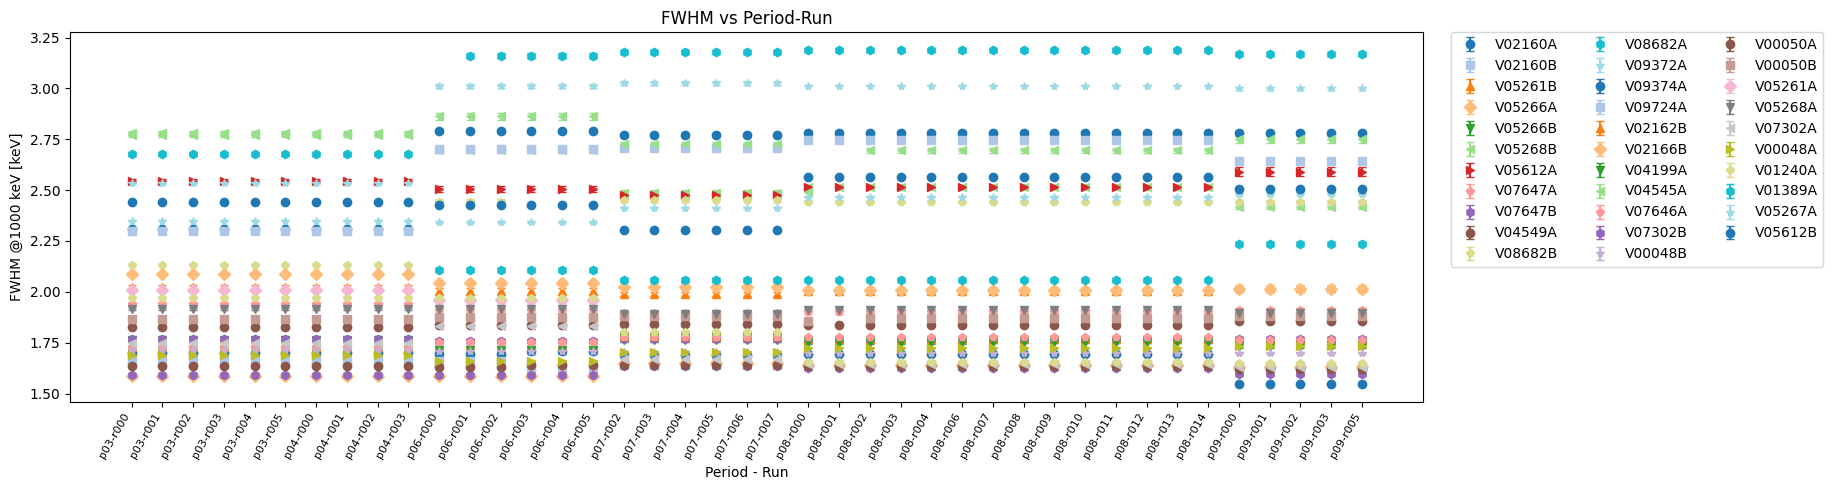

In [23]:
ICPC = [name for name in chmap.group('type')['icpc'].map('name')]

rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=ICPC[:int(len(ICPC)/2)],
    energy=1000,
    fig_path="plots/grouping/ICPC-1.png",
)


rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=ICPC[int(len(ICPC)/2):],
    energy=1000,
    fig_path="plots/grouping/ICPC-2.png",
)


rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=ICPC,
    energy=1000,
    fig_path="plots/grouping/ICPC-tot.png",
)


In [ ]:
rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=ICPC,
    energy=1000,
    fig_path="plots/grouping/ICPC-tot.png",
)

In [28]:
ICPC_group1 = [
    'V05612B',
    'V09724A',
    'V05267A',
    'V05612A',
    'V08682B',
    'V05268B',
    'V08682A',
    'V09372A',
    'V09374A',
    'V04545A'
]
ICPC_group2 = [det for det in ICPC if det not in ICPC_group1]

ICPC_group1.sort()
ICPC_group2.sort()

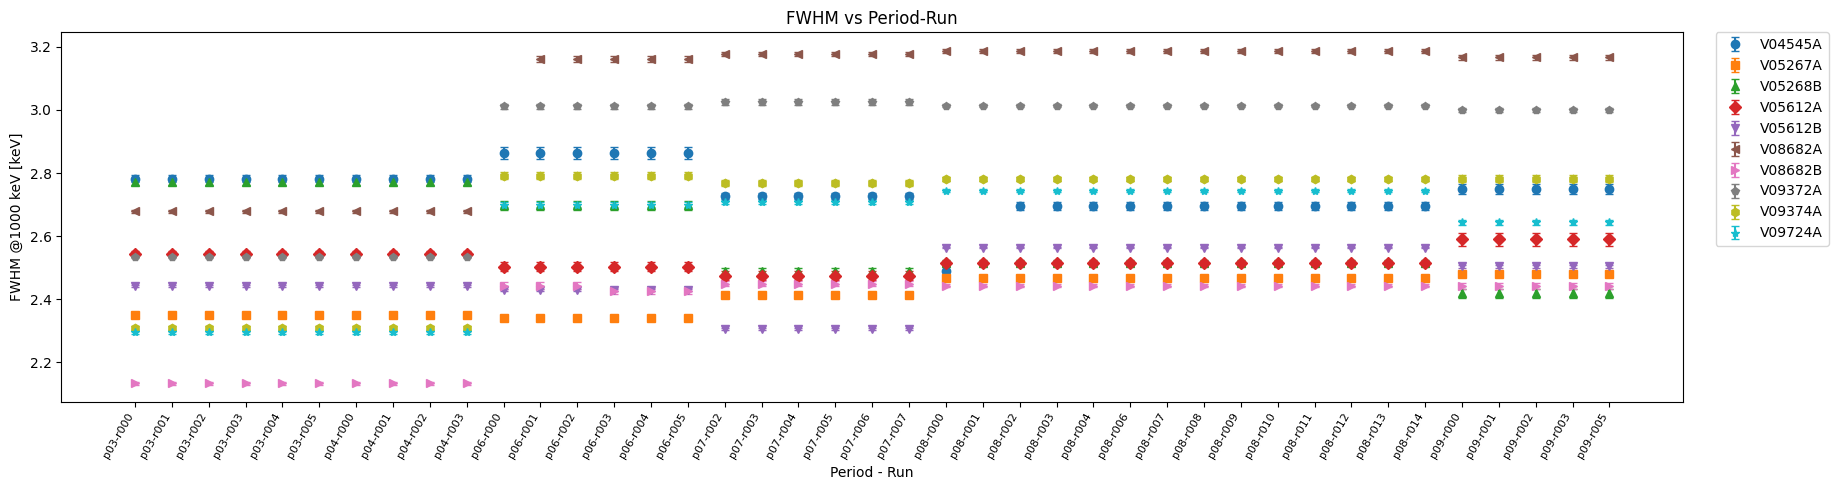

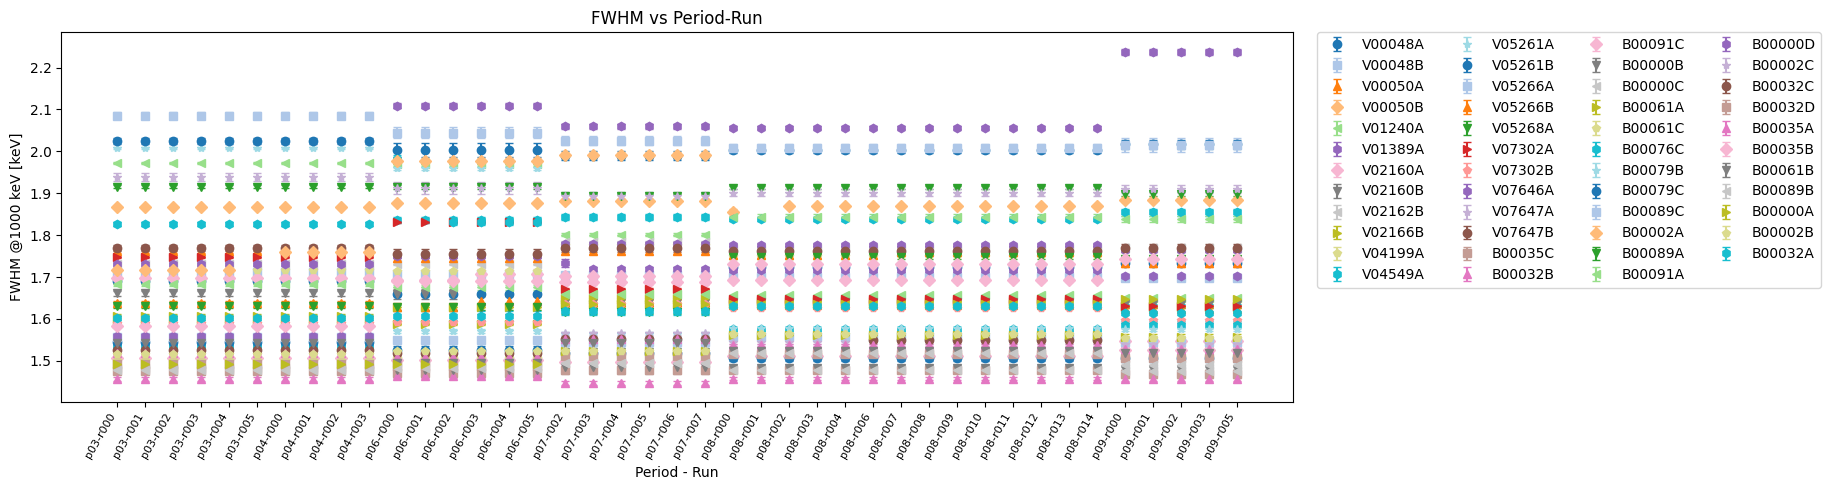

In [38]:
rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=ICPC_group1,
    energy=1000,
    fig_path="plots/grouping/ICPC-group1.png",
)

rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=ICPC_group2 + BEGe,
    energy=1000,
    fig_path="plots/grouping/ICPC-group2.png",
)

In [39]:
test1 = BEGe + PPC

In [ ]:
rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=test1,
    energy=1000,
    fig_path="plots/grouping/test1.png",
)

In [9]:
dictionaries_dir_old = "../data/inputs/dictionaries/"
groups_dict = Props.read_from(f"{dictionaries_dir_old}/detector-grouping/groups_dict.yaml")
eres_dict = Props.read_from(f"{dictionaries_dir_old}/eres_dict.yaml")

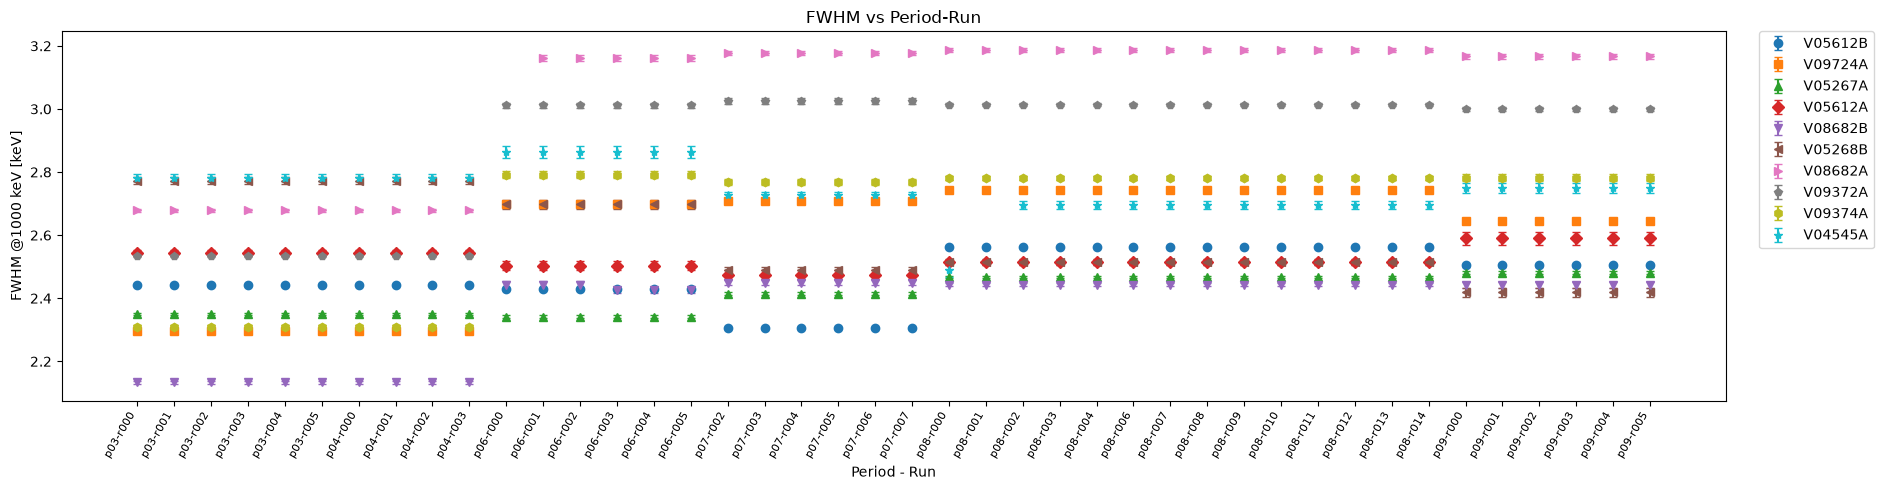

In [17]:
rex.plot_fwhm_vs_period_run_overlay(
    eres_dict,
    detectors=groups_dict['ICPC group1'],
    energy=1000,
    fig_path="../plots/grouping/test2.png",
)

In [16]:
groups_dict['ICPC group1'].pop("V01389A")

{'p09': 'all'}